<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 7: The Exponential Function

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#power" style="color:black;">The Exponential Function and Its Power Series</a></li>
    <li><a href="#background_convergence" style="color:#1B5E20;"><strong>Background:</strong> Why the Exponential Series Converges</a></li>    
    <li><a href="#complex_exp" style="color:black;">The Complex Exponential Function</a></li>    
    <li><a href="#euler" style="color:black;">Exponentiation Identity and Euler's Formula</a></li>
    <li><a href="#background_euler" style="color:#1B5E20;"><strong>Background:</strong> Euler's Identity and Mathematical Beauty</a></li>
    <li><a href="#differential" style="color:black;">Exponential Growth and Differential Equations</a></li>
    <li><a href="#roots" style="color:black;">Roots of Unity</a></li>
    <li><a href="#exercise_approx_exp" style="color:#006064;"><strong>Exercise 1:</strong> Approximating the Exponential Function</a></li>
    <li><a href="#exercise_gaussian" style="color:#006064;"><strong>Exercise 2:</strong> Exploring Gaussian Functions</a></li>
    <li><a href="#exercise_spiral" style="color:#006064;"><strong>Exercise 3:</strong> Generating Complex Spirals</a></li>
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
You may already know the <strong>exponential function</strong> from school as a model for growth and decay. A familiar example is money in a bank account that earns a fixed percentage of interest: each interest payment is based on the current balance, so the amount grows exponentially over time. In this unit, however, we take a broader view. We define the exponential function through its power series and extend its input from real numbers $x\in\mathbb{R}$ to complex numbers $z\in\mathbb{C}$. This extension reveals properties that are particularly important for the topics studied in this course. For real inputs, the exponential function describes changes in magnitude. For purely <strong>imaginary inputs</strong>, its values lie on the <strong>unit circle</strong>. Euler's formula connects these values directly to sine and cosine, allowing angles and rotations to be expressed through complex numbers. Complex exponentials therefore provide a natural language for oscillations and form the mathematical foundation of the Fourier transform and discrete Fourier transform studied in <a href="PCP_09_dft.html">Unit 9</a>.
</p>

<p style="color:#E65100;">
We introduce the exponential function using its <strong>power series</strong> and study its exponentiation identity, which transforms the addition of two input values into the multiplication of their exponential values. We then interpret the exponential function from the perspective of differential equations. Finally, we use complex exponentials to construct roots of unity, which will later become the building blocks of the discrete Fourier transform. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Approximate the exponential function using a finite number of terms from its power series.</li>
<li>Evaluate and interpret the exponential function for real and complex arguments.</li>
<li>Use the exponentiation identity and Euler's formula to relate complex exponentials to sine and cosine.</li>
<li>Explain why the exponential function solves the differential equation $f'(x)=f(x)$.</li>
<li>Approximate this differential equation numerically using Euler's method.</li>
<li>Construct and visualize <strong>roots of unity</strong> in the complex plane.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_approx_exp">Exercise 1</a>: Implement and compare two approximations of the exponential function.</li>
<li><a href="#exercise_gaussian">Exercise 2</a>: Compute and visualize Gaussian functions with different parameters.</li>
<li><a href="#exercise_spiral">Exercise 3</a>: Generate complex spirals by combining changing radii and angles.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The central idea is a remarkable change of perspective: extending the exponential function from $\mathbb{R}$ to $\mathbb{C}$ transforms a familiar function for growth and decay into a powerful tool for describing rotation and oscillation.
</p>

</div>

In [3]:
# --- Core scientific stack ---
from math import gcd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# --- Custom utilities (Unit 7) ---
from libpcp.unit07 import (
    exercise_approx_exp,
    exercise_gaussian,
    exercise_spiral,
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="power"></a>

## The Exponential Function and Its Power Series

The **real exponential function** $\exp:\mathbb{R}\to\mathbb{R}_{>0}$ appears throughout mathematics and can be characterized in several equivalent ways. One intuitive approach comes from compound interest. In the late seventeenth century, [Jacob Bernoulli](https://en.wikipedia.org/wiki/Jacob_Bernoulli) investigated what happens when interest is added to an account increasingly often.

Suppose an initial amount of $1$ earns interest at an annual rate $x$, where $x=0.05$, for example, corresponds to $5%$. With monthly compounding, the current balance is multiplied by $1+x/12$ twelve times. The balance after one year is therefore

$$
\left(1+\frac{x}{12}\right)^{12}.
$$

With daily compounding, the annual rate is divided among $365$ periods, resulting in

$$
\left(1+\frac{x}{365}\right)^{365}.
$$

More generally, dividing the interest among $n$ equally spaced periods gives the balance

$$
\left(1+\frac{x}{n}\right)^n.
$$

As $n$ increases, increasingly small portions of interest are added increasingly often. Letting $n$ tend to infinity leads to **continuous compounding** and the limit

$$
\exp(x):=\lim_{n\to\infty}
\left(1+\frac{x}{n}\right)^n.
$$

For $x=1$, this limit gives **Euler's number**

$$
e:=\exp(1)\approx2.71828.
$$

[Leonhard Euler](https://en.wikipedia.org/wiki/Leonhard_Euler) used the symbol $e$ systematically and developed many fundamental properties of the exponential function. The function is therefore also written as $\exp(x)=e^x$.

An equivalent representation is given by the **power series**

$$
\exp(x)=\sum_{n=0}^{\infty}\frac{x^n}{n!}
=1+x+\frac{x^2}{2!}+\frac{x^3}{3!}+\cdots,
\qquad x\in\mathbb{R},
$$

where $0!:=1$ and $n!:=1\cdot2\cdots n$ for every positive integer $n$. The first $N+1$ terms form the **partial sum**

$$
S_N(x):=\sum_{n=0}^{N}\frac{x^n}{n!}.
$$

Neither the existence of the compounding limit nor the convergence of the infinite series is automatic. One must also show that both constructions produce the same function. We use these standard mathematical results without proof. The convergence of the exponential series will be examined more closely in the background box on [why the exponential series converges](#background_convergence).

A computer cannot add infinitely many terms. Instead, it uses a finite partial sum $S_N(x)$ to approximate $\exp(x)$. The approximation generally improves as more terms are included, although the required value of $N$ depends on the input and the desired accuracy. We will investigate this relationship in <a href="#exercise_approx_exp">Exercise 1</a>.

NumPy provides the function [`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) for evaluating the exponential function at individual values or complete arrays:

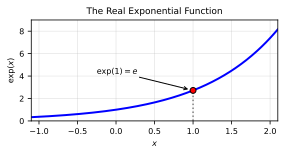

In [58]:
x = np.linspace(-1.1, 2.1, 321)
y = np.exp(x)
e = np.exp(1)

plt.figure(figsize=(4, 2.2), layout='tight')
plt.plot(x, y, color='blue', linewidth=2)
plt.plot([1, 1], [0, e], color='gray', linestyle=':')
plt.scatter(1, e, color='red', edgecolor='black', s=35, zorder=3)
plt.annotate(r'$\exp(1)=e$', xy=(1, e), xytext=(-0.25, 4.2),
             arrowprops=dict(arrowstyle='->', shrinkA=0, shrinkB=-5, color='black'))

plt.xlim(-1.1, 2.1)
plt.ylim(0, 9)
plt.xlabel('$x$')
plt.ylabel(r'$\exp(x)$')
plt.title('The Real Exponential Function')
plt.grid(alpha=0.3);

The graph shows several characteristic properties of the real exponential function. Its values are always positive, it passes through the point $(0,1)$, and the highlighted point satisfies $\exp(1)=e$. As $x$ increases, the function grows increasingly rapidly. As $x$ tends to $-\infty$, the function values approach zero without ever becoming zero.

The bank-account example motivates the exponential function only for real inputs: an interest rate is a real quantity, and a complex interest rate has no natural interpretation in this example. The power series, however, is constructed using addition, multiplication, integer powers, and division by the real numbers $n!$. These operations are also defined for complex numbers. Replacing the real input $x$ by a complex input $z$ therefore produces a meaningful series with complex-valued terms. To use this series as a definition, we must additionally know that it converges for every $z\in\mathbb{C}$. This leads to the complex exponential function introduced in the next section.

<a id="background_convergence"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Why the Exponential Series Converges
</h2>

<p style="color:#1B5E20;">
You may already know one of the most famous infinite sums:
$$
1+\frac12+\frac14+\frac18+\cdots=2.
$$
Starting with $1$, we repeatedly add half as much as before. The partial sums approach $2$ without exceeding it. This is the case $p=1/2$ of the <strong>geometric series</strong> $\sum_{n=0}^{\infty}p^n=1/(1-p)$, which converges for $0\leq p<1$. Not every infinite sum behaves so well. The <strong>harmonic series</strong> $\sum_{n=1}^{\infty}1/n=1+1/2+1/3+\cdots$ diverges to infinity even though its individual terms approach zero. The fact that the terms approach zero is therefore necessary for convergence, but it is not sufficient.
</p>

<p style="color:#1B5E20;">
In general, the infinite series $\sum_{n=0}^{\infty}a_n$ is defined through its partial sums $S_N:=\sum_{n=0}^{N}a_n$. It <strong>converges</strong> if $S_N$ approaches a finite limit as $N\to\infty$; this limit is then called the value of the series. If no finite limit exists, the series diverges. A stronger property is <a href="https://en.wikipedia.org/wiki/Absolute_convergence"><strong>absolute convergence</strong></a>: the series $\sum_{n=0}^{\infty}a_n$ converges absolutely if $\sum_{n=0}^{\infty}|a_n|$ converges. Taking absolute values removes signs and, for complex numbers, directions. Convergence then cannot depend on cancellation between terms. Absolute convergence always implies convergence, but the reverse implication does not always hold.
</p>

<p style="color:#1B5E20;">
We now apply these ideas to the complex exponential series
$$
\exp(z)=\sum_{n=0}^{\infty}\frac{z^n}{n!}
=1+z+\frac{z^2}{2!}+\frac{z^3}{3!}+\cdots,
\qquad z\in\mathbb{C}.
$$
For $z=0$, all terms except the first vanish, and the series has the value $1$. Now fix any $z\neq0$. The ratio of the magnitudes of two consecutive terms is
$$
\frac{|z|^{n+1}/(n+1)!}{|z|^n/n!}
=\frac{|z|}{n+1}.
$$
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Although $|z|$ may be large, it remains fixed while $n+1$ grows without bound. We can therefore choose an index $N$ such that $|z|/(n+1)\leq1/2$ for every $n\geq N$. From that point onward, each term is at most half as large as the preceding one. If $b_N:=|z|^N/N!$, the remaining magnitudes satisfy
$$
b_N+b_{N+1}+b_{N+2}+\cdots
\leq
b_N\left(1+\frac12+\frac1{2^2}+\cdots\right)
=2b_N.
$$
The tail is therefore bounded by a convergent geometric series. The finitely many terms before $N$ cannot cause divergence, so $\sum_{n=0}^{\infty}|z|^n/n!$ has a finite value. Thus, the exponential power series converges absolutely for every $z\in\mathbb{C}$. No matter how large the fixed modulus $|z|$ is, one only needs to go far enough along the series for the factorial to win the race against the power $|z|^n$.
</p>

</div>

## The Complex Exponential Function

The preceding [background box](#background_convergence) showed that the exponential power series converges absolutely for every complex input. We can therefore use the same series to define the **complex exponential function** $\exp:\mathbb{C}\to\mathbb{C}$:

$$
\exp(z):=\sum_{n=0}^{\infty}\frac{z^n}{n!}
=1+z+\frac{z^2}{2!}+\frac{z^3}{3!}+\cdots,
\qquad z\in\mathbb{C}.
$$

When $z$ is real, this series is identical to the real power series introduced above. The complex exponential function is therefore an **extension** of the real exponential function: it preserves all familiar values on the real axis while additionally assigning values to inputs with nonzero imaginary parts. NumPy uses the same function [`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) for real and complex inputs:

In [61]:
z = 1 + 0.5j
w = np.exp(z)

print('z:                   ', z)
print('exp(z):              ', w)
print('Real part of exp(z): ', np.real(w))
print('Imaginary part:      ', np.imag(w))
print('Modulus of exp(z):   ', np.abs(w))

z:                    (1+0.5j)
exp(z):               (2.3855167309591354+1.3032137296869954j)
Real part of exp(z):  2.3855167309591354
Imaginary part:       1.3032137296869954
Modulus of exp(z):    2.7182818284590446


Unlike the real exponential function, which produces positive real values, the complex exponential function maps a complex input $z\in\mathbb{C}$ to a complex output $\exp(z)\in\mathbb{C}$. Writing $z=x+iy$ identifies the input with the point $(x,y)$, where $x=\operatorname{Re}(z)$ and $y=\operatorname{Im}(z)$. Similarly, the output is described by its real part and imaginary part:

$$
\exp(z)=\operatorname{Re}(\exp(z))
+i\operatorname{Im}(\exp(z))
$$

The following figure evaluates $\exp(z)$ on a rectangular grid of input points $(x,y)$. In all three panels, the axes represent $\operatorname{Re}(z)$ and $\operatorname{Im}(z)$. The colors show different properties of the corresponding output: $\operatorname{Re}(\exp(z))$, $\operatorname{Im}(\exp(z))$, and $|\exp(z)|$, respectively:

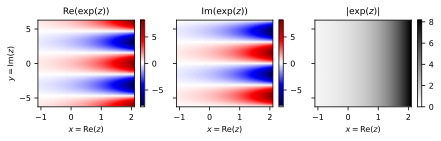

In [69]:
x = np.linspace(-1.1, 2.1, 81)
y = np.linspace(-2 * np.pi, 2 * np.pi, 161)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
E = np.exp(Z)
extent = [x[0], x[-1], y[0], y[-1]]
limit = np.exp(x[-1])

plots = [
    (E.real, r'$\operatorname{Re}(\exp(z))$', 'seismic', -limit, limit),
    (E.imag, r'$\operatorname{Im}(\exp(z))$', 'seismic', -limit, limit),
    (np.abs(E), r'$|\exp(z)|$', 'gray_r', 0, limit),
]

fig, axes = plt.subplots(1, 3, figsize=(6.2, 2), layout='tight', sharey=True)

for ax, (values, title, cmap, vmin, vmax) in zip(axes, plots):
    image = ax.imshow(
        values, cmap=cmap, origin='lower', aspect='auto',
        extent=extent, vmin=vmin, vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel(r'$x=\operatorname{Re}(z)$')
    fig.colorbar(image, ax=ax)

axes[0].set_ylabel(r'$y=\operatorname{Im}(z)$');

Several patterns are visible in the figure. In the first two panels, the real and imaginary parts of $\exp(z)$ oscillate as the imaginary coordinate $y$ changes. These oscillations repeat after $2\pi$, while their amplitudes increase as the real coordinate $x$ increases. In the third panel, the modulus changes only in the horizontal direction and remains constant along every vertical line. It therefore appears to depend on $x=\operatorname{Re}(z)$ but not on $y=\operatorname{Im}(z)$. At this stage, these are observations from a numerical visualization. The next section explains them mathematically. Euler's formula will show that the real part $x$ controls the modulus of $\exp(x+iy)$, while the imaginary part $y$ controls its angle. The complex exponential function thereby connects two seemingly different behaviors: exponential growth and rotation.

<a id="euler"></a>

## Euler’s Formula: From Growth to Rotation

Starting from the power-series definition, one can prove two famous formulas that explain many properties of the exponential function. The first is the **exponentiation identity**

$$
\exp(z_1+z_2)=\exp(z_1)\exp(z_2),
\qquad z_1,z_2\in\mathbb{C}.
$$

Thus, adding inputs corresponds to multiplying their exponential values. For a positive integer $n$, repeated application gives

$$
\exp(n)
=\exp(\underbrace{1+\cdots+1}_{n\text{ terms}})
=\underbrace{\exp(1)\cdots\exp(1)}_{n\text{ factors}}
=e^n.
$$

This illustrates exponential growth for real inputs: increasing the input by $1$ multiplies the output by the constant factor $e$. For a complex input $z=x+iy$, the same identity gives $\exp(x+iy)=\exp(x)\exp(iy)$. The positive real factor $\exp(x)$ controls the magnitude, while the meaning of $\exp(iy)$ is revealed by **Euler’s formula**:

$$
\exp(iy)=\cos(y)+i\sin(y),
\qquad y\in\mathbb{R}.
$$

Euler’s formula can be derived from the power-series definitions. Substituting $iy$ into the exponential series and using $i^2=-1$ separates the result into real and imaginary parts. These are precisely the familiar cosine and sine functions: on the unit circle, $\cos(y)$ is the horizontal coordinate of the point at angle $y$, while $\sin(y)$ is its vertical coordinate. Euler’s formula combines both coordinates into the single complex number $\cos(y)+i\sin(y)$.

Since $\cos^2(y)+\sin^2(y)=1$, the number $\exp(iy)$ has modulus $1$. As $y$ increases, it moves counterclockwise around the unit circle. Combining Euler’s formula with the exponentiation identity gives

$$
\exp(x+iy)
=\exp(x)\bigl(\cos(y)+i\sin(y)\bigr).
$$

This explains the preceding visualization: the real part $x$ of the input determines the modulus $|\exp(x+iy)|=\exp(x)$, while the imaginary part $y$ determines the angle. In particular,

$$
\operatorname{Re}(\exp(x+iy))=\exp(x)\cos(y),
\qquad
\operatorname{Im}(\exp(x+iy))=\exp(x)\sin(y).
$$

The complex exponential therefore combines **growth through the real part of its input** with **rotation through the imaginary part**. To examine the rotational component separately, consider the purely imaginary input $i\gamma$, where $\gamma\in\mathbb{R}$ is interpreted as an angle measured in radians. As $\gamma$ increases from $0$ to $2\pi$, the value $\exp(i\gamma)$ completes one counterclockwise turn around the unit circle. The following figure shows this motion in polar coordinates and, in the two panels on the right, the corresponding real and imaginary parts as functions of $\gamma$. Matching colors identify the same angle in all three panels:

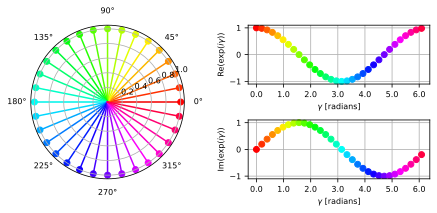

In [96]:
cmap = plt.get_cmap('hsv')  # hsv is nice because it defines a circular colormap
N = 32

fig = plt.figure(figsize=(6.2, 3), layout='tight')
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])
ax1 = fig.add_subplot(gs[:, 0], projection='polar')
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

for i in range(N):
    gamma = 2 * np.pi * i / N
    c = np.exp(1j * gamma)
    color = cmap(i / N)
    ax1.yaxis.set_zorder(5)
    ax1.plot([gamma, gamma], [0, np.abs(c)], color=color)
    ax1.plot(gamma, np.abs(c), 'o', color=color)
    ax2.plot(gamma, np.real(c), 'o', color=color)
    ax3.plot(gamma, np.imag(c), 'o', color=color)
    
ax2.grid()
ax2.set_xlabel(r'$\gamma$ [radians]')
ax2.set_ylabel(r'$\operatorname{Re}(\exp(i\gamma))$')
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%s$'))

ax3.grid()
ax3.set_xlabel(r'$\gamma$ [radians]')
ax3.set_ylabel(r'$\operatorname{Im}(\exp(i\gamma))$')
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%s$'));

We have seen from Euler's formula that $\exp(i\gamma)$ lies on the unit circle for every $\gamma\in\mathbb{R}$. The number $\gamma$ specifies its angle in radians, while $|\exp(i\gamma)|=1$. Because the values repeat after a complete turn, it suffices to consider $\gamma\in[0,2\pi)$. The exponentiation identity and Euler’s formula imply

$$
\begin{aligned}
\exp(i\gamma) &= \exp\bigl(i(\gamma+2\pi)\bigr),\\
|\exp(i\gamma)| &= 1,\\
\overline{\exp(i\gamma)} &= \exp(-i\gamma),\\
\exp\bigl(i(\gamma_1+\gamma_2)\bigr)
&= \exp(i\gamma_1)\exp(i\gamma_2).
\end{aligned}
$$

Substituting Euler's formula into the final identity and comparing real and imaginary parts gives the familiar angle-addition formulas

$$
\begin{aligned}
\cos(\gamma_1+\gamma_2)
&=\cos(\gamma_1)\cos(\gamma_2)-\sin(\gamma_1)\sin(\gamma_2),\\
\sin(\gamma_1+\gamma_2)
&=\cos(\gamma_1)\sin(\gamma_2)+\cos(\gamma_2)\sin(\gamma_1).
\end{aligned}
$$

<a id="background_euler"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Euler’s Identity and Mathematical Beauty
</h2>

<p style="color:#1B5E20;">
Euler’s formula describes the complex exponential at every angle. Choosing the particular angle $\pi$ gives
$$
\exp(i\pi)=\cos(\pi)+i\sin(\pi)=-1.
$$
Adding $1$ to both sides produces the celebrated <a href="https://en.wikipedia.org/wiki/Euler%27s_identity"><strong>Euler’s identity</strong></a>
$$
\boxed{\exp(i\pi)+1=0}.
$$
</p>

<p style="color:#1B5E20;">
This short equation brings together five fundamental mathematical constants: $0$, the additive identity; $1$, the multiplicative identity; $e$, the base of the exponential function; $i$, the imaginary unit; and $\pi$, the constant relating a circle’s circumference to its diameter. It also combines the basic operations of addition, multiplication, and exponentiation in a single exact statement.
</p>

<p style="color:#1B5E20;">
The identity is more than an attractive arrangement of famous symbols. It condenses a deep relationship between exponential growth, complex numbers, trigonometric functions, and the geometry of the circle. Starting at the point $1$ in the complex plane, multiplication by $\exp(i\gamma)$ produces a rotation through the angle $\gamma$. For $\gamma=\pi$, this is a half-turn around the unit circle, carrying $1$ precisely to $-1$. The equation $\exp(i\pi)+1=0$ expresses this geometric fact algebraically.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Euler’s identity is often described as one of the most beautiful equations in mathematics. Mathematical beauty is a matter of judgment rather than a theorem, but the admiration has a clear source: a remarkably compact formula reveals an unexpected connection among ideas that initially appear unrelated. <strong>In one line, growth becomes rotation, an angle becomes a complex number, and half a turn ends at $-1$.</strong>
</p>

</div>


<a id='differential'></a> 
## Differential Equations

The exponential function can be characterized by another important property in terms of differential equations. Let us consider the differential equation $\frac{df}{dx}(x)=f(x)$ with initial condition $f(0)=1$. The [**Picard&ndash;Lindelöf Theorem**](https://en.wikipedia.org/wiki/Picard%E2%80%93Lindel%C3%B6f_theorem) implies that there exists a unique solution. Using the power series definition, one can easily check that the exponential function indeed fulfills these properties. The differential equation also holds for the complex exponential function. In particular, one obtains the following equations:

\begin{eqnarray*}
\frac{d\exp(x)}{dx} & = & \exp(x)\\
\frac{d\exp(z)}{dz} & = & \exp(z)\\
\frac{d\exp(i\gamma)}{d\gamma} & = & i\exp(i\gamma)
\end{eqnarray*}

There are many numerical methods for approximating solutions of differential equations with initial conditions. The easiest method is known as **Euler's method**, where one starts with the initial value and then uses a tangent line over a short step size to estimate the function's value at the next step. In the next code cell, we implement this procedure for the case of the real exponential function. The figure shows the approximative solution compared to the NumPy function `np.exp`. To better understand the quality of the solution of the interval considered, we apply `plt.semilogy` for plotting.

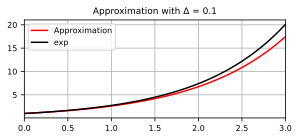

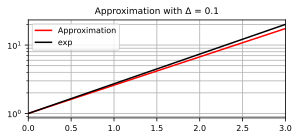

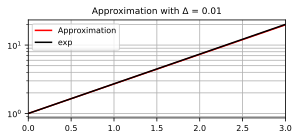

In [ ]:
def exp_approx_Euler(x_min=0, x_max=2, x_delta=0.01, f_0=1):
    """Approximation of exponential function using Euler's method

    Notebook: PCP_07_exp.ipynb

    Args:
        x_min: Start of input interval (Default value = 0)
        x_max: End of input interval (Default value = 2)
        x_delta: Step size (Default value = 0.01)
        f_0: Initial condition (Default value = 1)

    Returns:
        f: Signal
        x: Sampled input interval
    """
    x = np.arange(x_min, x_max+x_delta, x_delta)
    N = len(x)
    f = np.zeros(N)
    f[0] = f_0
    for n in range(1, N):
        f[n] = f[n-1] + f[n-1]*x_delta
    return f, x


x_max = 3
x_delta = 0.1
f, x = exp_approx_Euler(x_min=0, x_max=x_max, x_delta=x_delta, f_0=1)

plt.figure(figsize=(4.2, 2), layout='tight')
plt.plot(x, f, 'r')
plt.plot(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid()
plt.title(r'Approximation with $\Delta$ = %.1f' % x_delta)

plt.figure(figsize=(4.2, 2), layout='tight')
plt.semilogy(x, f, 'r')
plt.semilogy(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid(which='both')
plt.title(r'Approximation with $\Delta$ = %.1f' % x_delta)

x_delta  = 0.01
f, x = exp_approx_Euler(x_min=0, x_max=x_max, x_delta=x_delta, f_0=1)
plt.figure(figsize=(4.2, 2), layout='tight')
plt.semilogy(x, f, 'r')
plt.semilogy(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid(which='both')
plt.title(r'Approximation with $\Delta$ = %.2f' % x_delta)

<a id='roots'></a> 
## Roots of Unity

Let $N \in \mathbb{N}_{>0}$ be a positive integer. A complex number $\rho \in \mathbb{C}$ is called an $N^\mathrm{th}$ **root of unity** if $\rho^N = 1$. It is not hard to see that there are exactly $N$ distinct $N^\mathrm{th}$ roots of unity, which are exactly the $N$ different roots of the polynomial $z^N-1$ (see also Exercise 2 of <a href="PCP_06_complex.html">Unit 6</a>). Additionally, if $\rho^n \neq 1$ for all $n\in [1:N-1]$, the root $\rho$ is called a **primitive** $N^\mathrm{th}$ root of unity. With the properties mentioned above, it is easy to see that $\rho_N:=\exp(2 \pi i / N)$ is such a **primitive** $N^\mathrm{th}$ root of unity. Furthermore, all $N^\mathrm{th}$ roots of unity can be generated by considering the powers of $\rho_N$:

$$1=\rho_N^0, \quad \rho_N^1, \quad \rho_N^2, \quad ...,\quad \rho_N^{N-1}$$

The following plot shows all roots of unity for different integers $N \in \mathbb{N}_{>0}$. The primitive roots are indicated in red. 

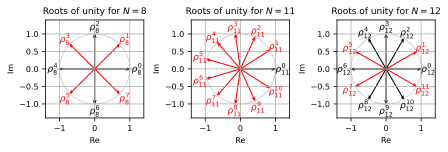

In [ ]:
def plot_vector(c, color='k', start=0, linestyle='-'):
    """Plotting complex number as vector

    Notebook: PCP_07_exp.ipynb

    Args:
        c: Complex number
        color: Vector color (Default value = 'k')
        start: Start of vector (Default value = 0)
        linestyle: Line Style of vector (Default value = '-')
    """
    return plt.arrow(np.real(start), np.imag(start), np.real(c), np.imag(c),
                     linestyle=linestyle, head_width=0.05,
                     fc=color, ec=color, overhang=0.3, length_includes_head=True)


def plot_root_unity(N, ax):
    """Plotting N-th root of unity into figure with axis

    Notebook: PCP_07_exp.ipynb

    Args:
        N: Root number
        ax: Axis handle
    """
    root_unity = np.exp(2j * np.pi / N)
    root_unity_power = 1

    ax.grid()
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim([-1.4, 1.4])
    ax.set_xlabel(r'$\mathrm{Re}$')
    ax.set_ylabel(r'$\mathrm{Im}$')
    ax.set_title('Roots of unity for $N=%d$' % N)

    for n in range(0, N):
        colorPlot = 'r' if gcd(n, N) == 1 else 'k'
        plot_vector(root_unity_power, color=colorPlot)
        ax.text(np.real(1.2*root_unity_power), np.imag(1.2*root_unity_power),
                r'$\rho_{%s}^{%s}$' % (N, n), size='9',
                color=colorPlot, ha='center', va='center')
        root_unity_power *= root_unity

    circle_unit = plt.Circle((0, 0), 1, color='lightgray', fill=0)
    ax.add_artist(circle_unit)
    ax.set_aspect('equal')

plt.figure(figsize=(6.2, 3), layout='tight')
ax = plt.subplot(1, 3, 1)
plot_root_unity(N=8, ax=ax)    
ax = plt.subplot(1, 3, 2)
plot_root_unity(N=11, ax=ax)
ax = plt.subplot(1, 3, 3)
plot_root_unity(N=12, ax=ax)

<a id='exercise_approx_exp'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Approximation of Exponential Function via Power Series</strong>
<p style="color:#006064;">
Implement a function <code>exp_power_series</code> with input arguments $z\in\mathbb{C}$ and $N\in\mathbb{N}$, which outputs an approximation $\sum_{n=0}^{N} \frac{z^n}{n!}$ of $\exp(z)$. Similarly, implement a function <code>exp_limit_compound</code> that approximates $\exp(z)$ via $\left(1+\frac{z}{N}\right)^{N}$. Test the two functions for various input arguments and compare the results with the NumPy function <code>np.exp</code>. In particular, compare the approximation quality of <code>exp_power_series</code> and <code>exp_limit_compound</code> for increasing $N$ (fixing a complex number $z$).
</p>
</div>

In [6]:
# Your Solution

In [7]:
exercise_approx_exp()

Input argument z = 1
N=  1, Numpy=2.7182818285, Approx1=2.0000000000, Approx2=2.0000000000
N=  2, Numpy=2.7182818285, Approx1=2.5000000000, Approx2=2.2500000000
N=  4, Numpy=2.7182818285, Approx1=2.7083333333, Approx2=2.4414062500
N=  8, Numpy=2.7182818285, Approx1=2.7182787698, Approx2=2.5657845140
N= 16, Numpy=2.7182818285, Approx1=2.7182818285, Approx2=2.6379284974
N= 32, Numpy=2.7182818285, Approx1=2.7182818285, Approx2=2.6769901294

Input argument z = (2.0, 0.7)
N=  1, Numpy=(5.6515, 4.7602), Approx1=(3.0000, 0.7000), Approx2=(3.0000, 0.7000)
N=  2, Numpy=(5.6515, 4.7602), Approx1=(4.7550, 2.1000), Approx2=(3.8775, 1.4000)
N=  4, Numpy=(5.6515, 4.7602), Approx1=(5.7850, 4.2618), Approx2=(4.6500, 2.3303)
N=  8, Numpy=(5.6515, 4.7602), Approx1=(5.6544, 4.7601), Approx2=(5.1527, 3.2239)
N= 16, Numpy=(5.6515, 4.7602), Approx1=(5.6515, 4.7602), Approx2=(5.4157, 3.8820)
N= 32, Numpy=(5.6515, 4.7602), Approx1=(5.6515, 4.7602), Approx2=(5.5401, 4.2885)
N= 64, Numpy=(5.6515, 4.7602), Appro

<a id='exercise_gaussian'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Gaussian Function</strong>
<p style="color:#006064;">
<a href="https://en.wikipedia.org/wiki/Gaussian_function ">Gaussian functions</a> are often used in statistics to represent the probability density function of a normally distributed random variable with expected value $\mu$ and variance $\sigma^2$. For these parameters, the Gaussian function $g:\mathbb{R}\to \mathbb{R}$ is defined by
$$
   g(x):= \frac{1}{\sigma\sqrt{2\pi}}  \exp\left(-\frac{1}{2} \left(\frac{x-\mu}{\sigma} \right)^2 \right).
$$
Using <code>np.exp</code>, implement a function <code>compute_gaussian_1D</code> that inputs a NumPy array <code>X</code> (as well as input arguments for $\mu$ and $\sigma$) and evaluates the Gaussian function <code>X</code> in a point-wise fashion. Plot the result for an input vector and various choices of $\mu$ and $\sigma$.
</p>
</div>

In [8]:
# Your Solution

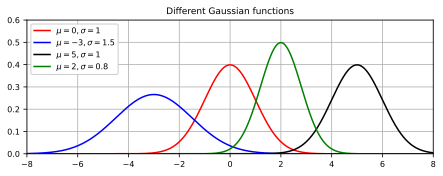

In [9]:
exercise_gaussian()

<a id='exercise_spiral'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Spiral  Generation</strong>
<p style="color:#006064;">
Implement a function <code>generate_spiral</code> that generates a spiral of increasing radius (Hint: Make use of the exponential function). The function should have the following arguments:
</p>
<ul style="color:#006064;">
    <li><code>rad_start</code>: Radius to start with</li>
    <li><code>rad_end</code>: Radius to stop with</li>
    <li><code>num_rot</code>: Number of rotations</li>
    <li><code>angle_start</code>: Angle to start with (given in degrees)</li>
    <li><code>N</code>: Number of data points to represent the spiral</li>
</ul>
<p style="color:#006064;">
Plot the spiral for various parameters.
</p>
</div>

In [10]:
# Your Solution

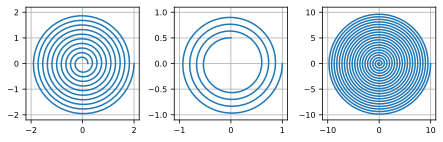

In [11]:
exercise_spiral()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>